# Stage 0: Signal Loading, Framing, and Windowing

This stage implements the preprocessing applied to each utterance prior to feature extraction. An audio signal is represented digitally as a sequence of amplitude samples recorded at a fixed sampling rate; for the Fluent Speech Commands corpus, the sampling rate is 16 kHz. As speech is a non-stationary signal, it is partitioned into short overlapping frames within which it can be treated as approximately stationary, and each frame is windowed prior to subsequent frequency-domain analysis.

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

DATA_ROOT = "../data/fluent_speech_commands_dataset"
WAV_PATH = f"{DATA_ROOT}/wavs/speakers/2BqVo8kVB2Skwgyb/ac4fca80-447a-11e9-a9a5-5dbec3b8816a.wav"
TRANSCRIPT = "Bring socks"

# sr=None keeps the file's native sample rate instead of resampling to librosa's 22050 Hz default.
# FSC is already 16 kHz mono, so this should just confirm that.
y, sr = librosa.load(WAV_PATH, sr=None)

duration_s = len(y) / sr
print(f"Transcript: {TRANSCRIPT!r}")
print(f"Sample rate: {sr} Hz")
print(f"Number of samples: {len(y)}")
print(f"Duration: {duration_s:.3f} s")
print(f"Amplitude range: [{y.min():.4f}, {y.max():.4f}]")
print(f"dtype: {y.dtype}")

Transcript: 'Bring socks'
Sample rate: 16000 Hz
Number of samples: 28235
Duration: 1.765 s
Amplitude range: [-0.0534, 0.0785]
dtype: float32


## Waveform

The time-domain waveform of the utterance is shown below. Regions of higher amplitude correspond to voiced or unvoiced speech activity, while near-zero regions correspond to silence.

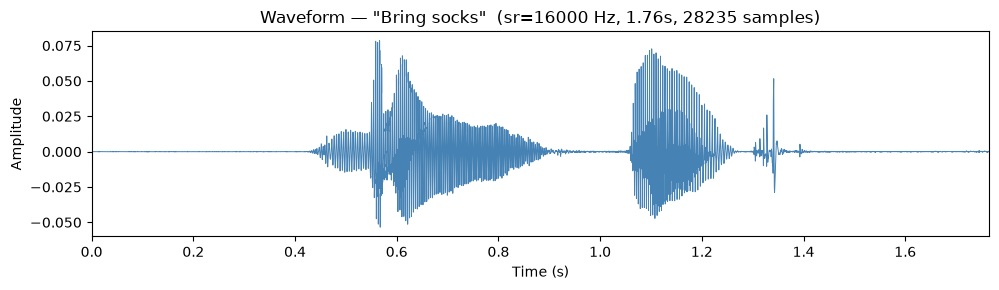

In [2]:
fig, ax = plt.subplots(figsize=(10, 3))
t = np.arange(len(y)) / sr
ax.plot(t, y, linewidth=0.7, color="steelblue")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f'Waveform — "{TRANSCRIPT}"  (sr={sr} Hz, {duration_s:.2f}s, {len(y)} samples)')
ax.set_xlim(0, duration_s)
fig.tight_layout()
plt.show()

## Framing

The signal is partitioned into frames of length 25 ms with a hop size of 10 ms, giving a 15 ms overlap between consecutive frames. A 25 ms frame length is a standard choice in speech processing: it is short enough that the vocal tract configuration can be assumed approximately static within a single frame, while remaining long enough to contain multiple pitch periods, which is necessary for reliable periodicity and frequency-domain analysis in later stages.

In [3]:
FRAME_MS = 25
HOP_MS = 10
frame_len = int(sr * FRAME_MS / 1000)   # samples per frame
hop_len = int(sr * HOP_MS / 1000)       # samples between frame starts

print(f"Frame length: {frame_len} samples ({FRAME_MS} ms)")
print(f"Hop length:   {hop_len} samples ({HOP_MS} ms)")

# librosa.util.frame slices y into overlapping frames without copying more than needed.
# Resulting shape: (frame_len, n_frames) - one column per frame.
frames = librosa.util.frame(y, frame_length=frame_len, hop_length=hop_len)
n_frames = frames.shape[1]
print(f"Number of frames: {n_frames}")

Frame length: 400 samples (25 ms)
Hop length:   160 samples (10 ms)
Number of frames: 174


## Windowing

Frame boundaries introduce discontinuities not present in the underlying continuous signal. As the discrete Fourier transform, applied in a later stage, treats each frame as implicitly periodic, an abrupt discontinuity at the frame edges introduces spurious energy across the frequency spectrum, an effect referred to as spectral leakage. A Hamming window is therefore applied to each frame, tapering the amplitude toward zero at the edges to reduce this artifact prior to frequency-domain analysis.

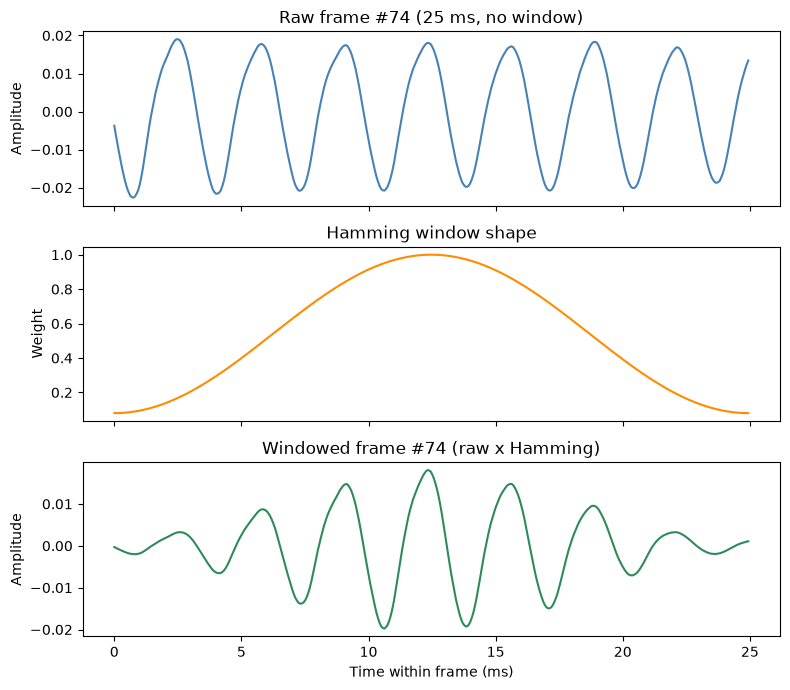

In [4]:
# Hamming window: tapers each frame's edges toward zero so the two ends meet smoothly
# when we later treat the frame as (implicitly) periodic for the DFT.
window = np.hamming(frame_len)

# Pick the frame at t=0.752s, the same voiced frame analyzed in later stages,
# so the illustration here is directly continuous with later results.
frame_times = (np.arange(n_frames) * hop_len + frame_len / 2) / sr
mid_idx = np.argmin(np.abs(frame_times - 0.752))
raw_frame = frames[:, mid_idx]
windowed_frame = raw_frame * window

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
frame_t = np.arange(frame_len) / sr * 1000  # ms, relative to frame start

axes[0].plot(frame_t, raw_frame, color="steelblue")
axes[0].set_title(f"Raw frame #{mid_idx} ({FRAME_MS} ms, no window)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(frame_t, window, color="darkorange")
axes[1].set_title("Hamming window shape")
axes[1].set_ylabel("Weight")

axes[2].plot(frame_t, windowed_frame, color="seagreen")
axes[2].set_title(f"Windowed frame #{mid_idx} (raw x Hamming)")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time within frame (ms)")

fig.tight_layout()
plt.show()

## Results

The loaded utterance ("Bring socks") has a sampling rate of 16 kHz and a duration of 1.765 s (28,235 samples), consistent with the corpus specification. The waveform exhibits two distinct high-amplitude regions separated by a lower-amplitude interval, corresponding to the two words of the utterance separated by a brief pause, along with lower-amplitude, higher-frequency activity corresponding to the /s/ sounds in "socks," examined in detail in later stages. Framing with a 25 ms window and 10 ms hop yields 174 overlapping frames. The frame inspected at t=0.752s (the same frame analyzed in Stages 2 and 4) exhibits a quasi-periodic structure of sharp spikes at approximately 3-4 ms intervals, consistent with glottal pulses in a voiced segment. Applying the Hamming window preserves this periodic structure while tapering the frame amplitude to near zero at both edges, as required to limit spectral leakage in the frequency-domain analysis performed in later stages.